In [90]:
%reload_ext autoreload
%autoreload 2
# %matplotlib qt
%matplotlib inline

import random
import numpy as np
import torch
from matplotlib import pyplot as plt
from syd import make_viewer, Viewer
from tqdm import tqdm

from vrAnalysis.database import get_database
from vrAnalysis.helpers import Timer
from vrAnalysis.helpers.plotting import format_spines, beeswarm, errorPlot, save_figure, add_scaled_limits
from vrAnalysis.processors.placefields import get_placefield
from dimilibi import PCA, SVCA
from dimensionality_manuscript.registry import PopulationRegistry, get_subspace, SubspaceName, RegistryPaths
from dimensionality_manuscript.subspace_analysis.base import Subspace
from dimensionality_manuscript.regression_models.hyperparameters import PlaceFieldHyperparameters
from dimensionality_manuscript.simulations import sqrtm_spd
from dimensionality_manuscript import SubspaceConfig, StimSpaceConfig, StimSpaceSpectraConfig
from dimensionality_manuscript import ResultsAggregator, ResultsStore, get_data_config
from dimensionality_manuscript.scripts.status import status
from dimensionality_manuscript.subspace_analysis.stimspace import StimSpaceSubspace
from dimensionality_manuscript.configs import PlaceFieldStructureConfig
from dimensionality_manuscript import average_by_mouse
plt.rcParams["font.size"] = 14

from dimensionality_manuscript.figure_scripts.figure3 import subspace_crossspace

# get session database
sessiondb = get_database("vrSessions")

# get population registry and models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
registry = PopulationRegistry()
registry_paths = RegistryPaths()
figure_path = registry_paths.figure_path / "figure3"
if not figure_path.exists():
    figure_path.mkdir(parents=True, exist_ok=True)

In [91]:
sessions = sessiondb.iter_sessions(imaging=True, experimentType="Blender VR")
store = ResultsStore()
cfg = StimSpaceSpectraConfig()
results = ResultsAggregator(cfg, store, sessions)
results_subspace = ResultsAggregator(SubspaceConfig, store, sessions)
results_pfstructure = ResultsAggregator(PlaceFieldStructureConfig, store, sessions)

C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:44: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(arr[mouse_names == mouse], axis=0)
C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\figure_scripts\figure3.py:1433: RuntimeWarning: Mean of empty slice


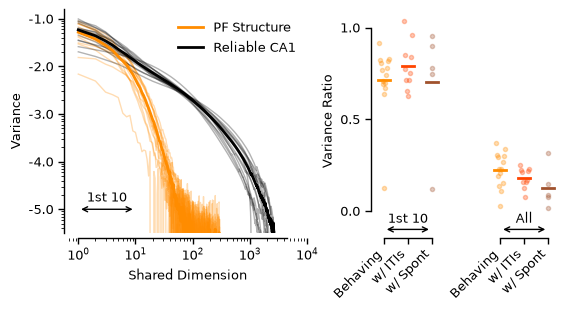

In [117]:
from dimensionality_manuscript.figure_scripts.figure3 import subspace_curves_ratios

return_syd_viewer = False
fig = subspace_curves_ratios(
    results,
    figsize=(5.5, 3.0),
    return_syd_viewer=return_syd_viewer,
)

if return_syd_viewer:
    fig.show()

else:
    plt.show()

    save = False
    if save:
        save_figure(fig, figure_path / "subspace_curves_ratios")

In [70]:
from dimensionality_manuscript.figure_scripts.figure3 import subspace_familiarity

return_syd_viewer = True
fig = subspace_familiarity(
    results, 
    plot_mode="all", 
    env_full_scope="within_env",
    full_within_env=False,
    within_condition=False,
    style="errorPlot",
    return_syd_viewer=return_syd_viewer,
    figsize=(5.0, 3.0),
)

if return_syd_viewer:
    fig.show()

else:
    plt.show()

    save = False
    if save:
        save_figure(fig, figure_path / "svr_over_familiarity")

In [48]:
return_syd_viewer = True
fig = subspace_familiarity(
    results, 
    plot_mode="by_env", 
    env_full_scope="within_env",
    full_within_env=False,
    style="errorPlot",
    return_syd_viewer=return_syd_viewer,
    figsize=(5.0, 3.0),
)

if return_syd_viewer:
    fig.show()

else:
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "svr_over_familiarity_by_env")

C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\figure_scripts\figure3.py:790: RuntimeWarning: invalid value encountered in divide
  ratio = np.nansum(sf, axis=1) / total


C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:44: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(arr[mouse_names == mouse], axis=0)
C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\figure_scripts\figure3.py:1438: RuntimeWarning: Mean of empty slice
C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\figure_scripts\figure3.py:1151: RuntimeWarning: invalid value encountered in divide
  


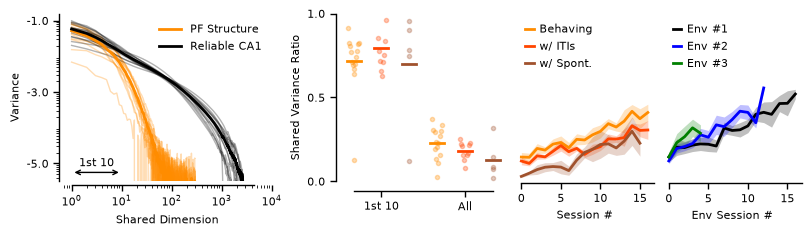

In [148]:
from dimensionality_manuscript.figure_scripts.figure3 import complete_spectrum_figure

return_syd_viewer = False
fig = complete_spectrum_figure(
    results,
    within_condition=False,
    style_all="errorPlot",
    env_full_scope="within_env",
    full_within_env=False,
    style_by_env="errorPlot",
    figsize=(8.0, 2.25),
    return_syd_viewer=return_syd_viewer,
    fontsize=8.0,
)

if return_syd_viewer:
    fig.show()

else:
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "complete_spectrum_figure")

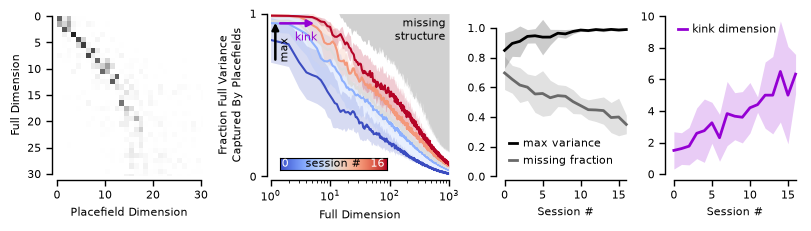

In [ ]:
from dimensionality_manuscript.figure_scripts.figure3 import subspace_crossspace

return_syd_viewer = True
fig = subspace_crossspace(
    results_subspace,
    idx_cross=2,
    plot_energy=True,
    num_cross_show=30,
    weighted=False,
    curve_mode="by_session",
    plot_style="errorPlot",
    hide_error=False,
    skip_sessions=3,
    curve_smooth_kind="median",
    curve_smooth_width=3,
    kink_threshold=0.975,
    max_arrow_x=1.2,
    max_arrow_y_start=0.7,
    max_arrow_y_end=0.965,
    kink_arrow_x_start=1.3,
    kink_arrow_x_end=6.0,
    kink_arrow_y=0.935,
    missing_structure_x_offset=10.0,
    missing_structure_y_offset=0.05,
    missing_structure_alpha=0.3,
    arrow_linewidth=1.75,
    arrow_head_size=0.25,
    return_syd_viewer=return_syd_viewer,
    figsize=(8.0, 2.2),
    fontsize=8.0,
)

if return_syd_viewer:
    fig.show()

else:
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "cross_space_analysis")

In [52]:
from dimensionality_manuscript.figure_scripts.figure3 import subspace_crossspace_per_mouse

return_syd_viewer = True
plt.close('all')
fig = subspace_crossspace_per_mouse(
    results_subspace,
    mouse = "ATL049",
    session = 14,
    num_cross_show = 30,
    curve_smooth_kind = "median",
    curve_smooth_width = 5,
    kink_threshold = 0.95,
    figsize = (8.0, 3.0),
    return_syd_viewer = return_syd_viewer,
)
if return_syd_viewer:
    fig.show()
else:
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "crossspace_familiarity_example")

In [94]:
# from dimensionality_manuscript.figure_scripts.figure3 import placefield_structure_over_time

# return_syd_viewer = True
# plt.close('all')
# fig = placefield_structure_over_time(
#     results_pfstructure,
#     env_slot=0,
#     feature_keys=["pf_mean", "pf_cv", "reliability", "fraction_active"],
#     style="all",
#     figsize=(8.0, 3.0),
#     return_syd_viewer=return_syd_viewer,
# )
# if return_syd_viewer:
#     fig.show()
# else:
#     plt.show()

#     save = True
#     if save:
#         save_figure(fig, figure_path / "placefield_structure_over_time")
